# 3.6 Combo — Lag + Social Media Models

Lag features combined with social media signals.

**Pipeline:** Gold → Model outputs  
**Input:** `Data/3_Gold/basetable_preprocessed.csv`  
**Output:** Model metrics and visualisations

<!-- toc -->
## Contents
- [Setup](#setup)
- [1. Load Data & Compute Target](#1-load-data-compute-target)
- [2. Train/Val/Test Split](#2-trainvaltest-split)
- [3. CV Folds](#3-cv-folds)
- [4. Helper Functions](#4-helper-functions)
- [5. Model 1 — Ridge Regression](#5-model-1-ridge-regression)
- [6. Model 2 — Random Forest Regressor](#6-model-2-random-forest-regressor)
- [7. Model 3 — Support Vector Regression (tuned kernel)](#7-model-3-support-vector-regression-tuned-kernel)
- [8. Model 4 — XGBoost Regressor](#8-model-4-xgboost-regressor)
- [9. Naive Baseline — Always Predict Zero](#9-naive-baseline-always-predict-zero)
- [10. Model Comparison](#10-model-comparison)


## Setup

In [2]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
try:
    from xgboost import XGBRegressor
except ImportError:
    raise ImportError("XGBoost not found. Install with: pip install xgboost")

from Functions.data_splits import (
    get_cv_folds, get_test_split, print_fold_summary, validate_no_leakage,
)
from Functions.evaluation_metrics import (
    directional_accuracy, compute_metrics, cv_evaluate, final_eval, tune_hyperparams,
)
from house_style import *
apply_style()

RANDOM_STATE = 42
TEST_DAYS    = 14
N_SPLITS     = 3
GAP          = 1

DATA_PATH = "../../../Data/3_Gold/basetable_preprocessed.csv"

LAG_COLS = [
    "polymarket_trump_prob_lag1",
    "polymarket_trump_prob_lag4",
    "price_change_lag1",
]

SOCIAL_COLS = [
    # ── Bluesky volume & author diversity ─────────────────────────────────────
    "bsky_trump_unique_authors", "bsky_harris_unique_authors",
    "bsky_trump_share", "bsky_harris_share", "bsky_posts_per_author",
    # ── Bluesky sentiment ─────────────────────────────────────────────────────
    "bsky_harris_sent_avg", "bsky_harris_pos_share", "bsky_harris_neg_share",
    "bsky_election_sent_avg", "bsky_election_sent_std",
    "bsky_election_pos_share", "bsky_election_neg_share",
    "bsky_sentiment_gap", "bsky_sentiment_gap_lag1",
    # ── Bluesky NRC emotions ──────────────────────────────────────────────────
    "bsky_trump_fear", "bsky_trump_trust", "bsky_trump_surprise",
    "bsky_trump_sadness", "bsky_trump_disgust", "bsky_trump_joy",
    "bsky_harris_fear", "bsky_harris_anger", "bsky_harris_anticipation",
    "bsky_harris_trust", "bsky_harris_disgust", "bsky_harris_joy",
    "bsky_election_surprise", "bsky_election_joy",
    # ── Reddit volume & engagement ────────────────────────────────────────────
    "reddit_unique_authors", "reddit_avg_score",
    "reddit_avg_upvote_ratio", "reddit_avg_comments",
    "reddit_harris_unique_authors", "reddit_harris_share",
    "reddit_conservative_share", "reddit_posts_per_author",
    # ── Reddit sentiment ──────────────────────────────────────────────────────
    "reddit_trump_sent_avg", "reddit_trump_sent_std",
    "reddit_harris_sent_std",
    "reddit_sentiment_gap", "reddit_sentiment_gap_lag1",
    # ── Reddit NRC emotions ───────────────────────────────────────────────────
    "reddit_trump_fear", "reddit_trump_anger", "reddit_trump_anticipation",
    "reddit_trump_trust", "reddit_trump_surprise", "reddit_trump_sadness",
    "reddit_trump_disgust", "reddit_trump_joy",
    "reddit_harris_anticipation", "reddit_harris_trust",
    "reddit_harris_sadness", "reddit_harris_disgust", "reddit_harris_joy",
    "reddit_election_fear", "reddit_election_anger", "reddit_election_anticipation",
    "reddit_election_surprise", "reddit_election_sadness", "reddit_election_joy",
    "reddit_election_sent_std",
]

COMBO_COLS = LAG_COLS + SOCIAL_COLS

MODEL_COLORS = {
    "Naive (zero)"    : NEUTRAL,
    "Ridge Regression" : PALETTE[0],
    "Random Forest"   : PALETTE[1],
    "SVM"             : PALETTE[4],
    "XGBoost"         : PALETTE[2],
}

print(f"Lag features    : {len(LAG_COLS)}")
print(f"Social features : {len(SOCIAL_COLS)}")
print(f"Total features  : {len(COMBO_COLS)}")
print("Imports OK")

Lag features    : 3
Social features : 61
Total features  : 64
Imports OK


## 1. Load Data & Compute Target

We load `basetable_preprocessed.csv` and combine lag + social media features.
Target: daily first-difference of Polymarket Trump probability.

In [3]:
df_raw = pd.read_csv(DATA_PATH, parse_dates=["date"])
df_raw = df_raw.sort_values("date").reset_index(drop=True)

missing = [c for c in COMBO_COLS if c not in df_raw.columns]
assert not missing, f"Missing columns: {missing} — re-run preprocessing.ipynb"

df = df_raw[["date"] + COMBO_COLS].copy()
df["target"] = df_raw["polymarket_trump_prob"] - df_raw["polymarket_trump_prob_lag1"]
df = df.dropna().reset_index(drop=True)

print(f"Rows            : {len(df)}")
print(f"Date range      : {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Total features  : {len(COMBO_COLS)}  ({len(LAG_COLS)} lag + {len(SOCIAL_COLS)} social)")
print(f"\nTarget (daily delta prob) stats:")
print(df["target"].describe().round(5))

Rows            : 123
Date range      : 2024-07-05 -> 2024-11-04
Total features  : 64  (3 lag + 61 social)

Target (daily delta prob) stats:
count    123.00000
mean      -0.00020
std        0.01782
min       -0.06000
25%       -0.01000
50%        0.00000
75%        0.00900
max        0.08000
Name: target, dtype: float64


## 2. Train/Val/Test Split

`get_test_split` carves off the **last 14 rows** as the held-out test set.

In [4]:
tv_idx, test_idx = get_test_split(df, test_days=TEST_DAYS)

df_tv   = df.iloc[tv_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

X_tv   = df_tv[COMBO_COLS].values
y_tv   = df_tv["target"].values
X_test = df_test[COMBO_COLS].values
y_test = df_test["target"].values

print(f"Train/val : {len(df_tv):>4} rows  ({df_tv['date'].min().date()} -> {df_tv['date'].max().date()})")
print(f"Test      : {len(df_test):>4} rows  ({df_test['date'].min().date()} -> {df_test['date'].max().date()})")

Train/val :  109 rows  (2024-07-05 -> 2024-10-21)
Test      :   14 rows  (2024-10-22 -> 2024-11-04)


## 3. CV Folds

**3 expanding-window folds** on the TV set with a 1-day gap.

In [5]:
folds = get_cv_folds(df_tv, n_splits=N_SPLITS, gap=GAP, test_days=None)
print_fold_summary(df_tv, folds)

print("\nLeakage validation:")
for i, (tr, va) in enumerate(folds, 1):
    validate_no_leakage(tr, va, df_tv, gap=GAP)
    print(f"  Fold {i}: OK")

Fold   Train start     Train end   #Train     Val start       Val end    #Val
-----------------------------------------------------------------------------
   1    2024-07-05    2024-07-31       27    2024-08-02    2024-08-28      27
   2    2024-07-05    2024-08-27       54    2024-08-29    2024-09-24      27
   3    2024-07-05    2024-09-23       81    2024-09-25    2024-10-21      27

Leakage validation:
  Fold 1: OK
  Fold 2: OK
  Fold 3: OK


## 4. Helper Functions

All helpers are imported from `Functions.evaluation_metrics`:
`tune_hyperparams`, `cv_evaluate`, `final_eval`, `compute_metrics`, `directional_accuracy`.

## 5. Model 1 — Ridge Regression

Ridge adds an L2 penalty to OLS: `β̂ = argmin ||y − Xβ||² + α||β||²`.
We tune `alpha` over a log-scale grid.

In [6]:
def make_ridge(alpha):
    return Ridge(alpha=alpha)

ridge_param_grid = {"alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 500.0, 1000.0]}

print("=== Ridge Regression — Hyperparameter Tuning ===")
ridge_best, ridge_tune_df = tune_hyperparams(
    make_ridge, ridge_param_grid, folds, X_tv, y_tv, scale=True
)
print(f"  Best params : {ridge_best}")
print(f"\n  All configurations (sorted by CV MAE):")
print(ridge_tune_df.to_string(index=False))

lr_factory = lambda: make_ridge(**ridge_best)
print("\n=== Ridge Regression — CV (best params) ===")
lr_cv = cv_evaluate(lr_factory, folds, X_tv, y_tv, scale=True)
lr_cv.round(4)

=== Ridge Regression — Hyperparameter Tuning ===
  Best params : {'alpha': 1000.0}

  All configurations (sorted by CV MAE):
   alpha   cv_mae  cv_mae_std
1000.000 0.010265    0.001753
 500.000 0.010304    0.001632
 100.000 0.011363    0.001147
  10.000 0.020372    0.005289
   1.000 0.031411    0.008863
   0.100 0.038793    0.011817
   0.010 0.041569    0.013792
   0.001 0.042010    0.014047

=== Ridge Regression — CV (best params) ===
  Fold 1: MAE=0.0114  RMSE=0.0150  DA=0.593  R2=0.0070
  Fold 2: MAE=0.0078  RMSE=0.0100  DA=0.444  R2=-0.0392
  Fold 3: MAE=0.0116  RMSE=0.0160  DA=0.296  R2=-0.2510
  -- Mean --  MAE=0.0103  RMSE=0.0137  DA=0.444  R2=-0.0944


,MAE,RMSE,Dir. Accuracy,R2
1,0.0114,0.0150,0.5926,0.0070
2,0.0078,0.0100,0.4444,-0.0392
3,0.0116,0.0160,0.2963,-0.2510
Mean,0.0103,0.0137,0.4444,-0.0944
Std,0.0021,0.0032,0.1481,0.1376


In [7]:
lr_model, lr_pred, lr_test = final_eval(
    lr_factory, X_tv, y_tv, X_test, y_test, scale=True
)
print("Ridge Regression — Test set:")
for k, v in lr_test.items():
    print(f"  {k}: {v:.4f}")

Ridge Regression — Test set:
  MAE: 0.0158
  RMSE: 0.0210
  Dir. Accuracy: 0.5714
  R2: -0.0788


## 6. Model 2 — Random Forest Regressor

We tune `max_depth` and `min_samples_leaf`.

In [9]:
def make_rf(max_depth, min_samples_leaf):
    return RandomForestRegressor(
        n_estimators=200,
        max_depth=int(max_depth),
        min_samples_leaf=int(min_samples_leaf),
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

rf_param_grid = {
    "max_depth"       : [2, 3, 4, 5],
    "min_samples_leaf": [1, 2, 3, 5],
}

print("=== Random Forest — Hyperparameter Tuning ===")
rf_best, rf_tune_df = tune_hyperparams(
    make_rf, rf_param_grid, folds, X_tv, y_tv, scale=False
)
print(f"  Best params : {rf_best}")
print(f"\n  Top-5 configurations (sorted by CV MAE):")
print(rf_tune_df.head(5).to_string(index=False))

rf_factory = lambda: make_rf(**rf_best)
print("\n=== Random Forest — CV (best params) ===")
rf_cv = cv_evaluate(rf_factory, folds, X_tv, y_tv, scale=False)
rf_cv.round(4)

=== Random Forest — Hyperparameter Tuning ===
  Best params : {'max_depth': 2, 'min_samples_leaf': 2}

  Top-5 configurations (sorted by CV MAE):
 max_depth  min_samples_leaf   cv_mae  cv_mae_std
         2                 2 0.010627    0.001605
         3                 2 0.010639    0.001698
         2                 3 0.010651    0.001861
         5                 5 0.010656    0.001671
         4                 5 0.010663    0.001674

=== Random Forest — CV (best params) ===
  Fold 1: MAE=0.0119  RMSE=0.0154  DA=0.481  R2=-0.0445
  Fold 2: MAE=0.0084  RMSE=0.0104  DA=0.556  R2=-0.1211
  Fold 3: MAE=0.0116  RMSE=0.0158  DA=0.370  R2=-0.2190
  -- Mean --  MAE=0.0106  RMSE=0.0139  DA=0.469  R2=-0.1282


,MAE,RMSE,Dir. Accuracy,R2
1,0.0119,0.0154,0.4815,-0.0445
2,0.0084,0.0104,0.5556,-0.1211
3,0.0116,0.0158,0.3704,-0.2190
Mean,0.0106,0.0139,0.4691,-0.1282
Std,0.0020,0.0030,0.0932,0.0875


Random Forest — Test set:
  MAE: 0.0159
  RMSE: 0.0212
  Dir. Accuracy: 0.5000
  R2: -0.0997


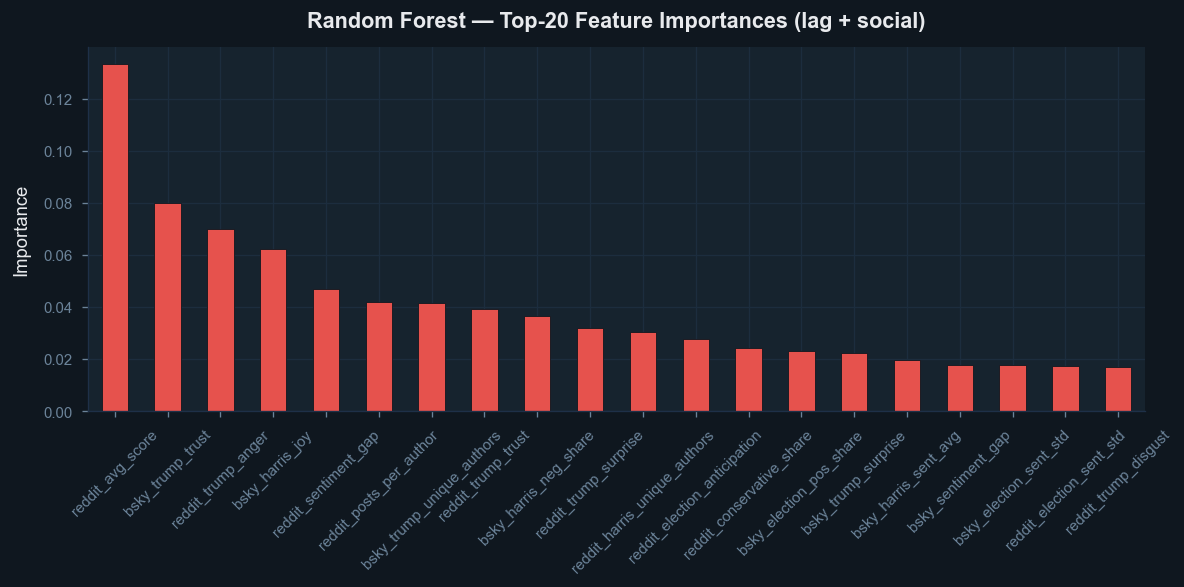

In [10]:
rf_model, rf_pred, rf_test = final_eval(
    rf_factory, X_tv, y_tv, X_test, y_test, scale=False
)
print("Random Forest — Test set:")
for k, v in rf_test.items():
    print(f"  {k}: {v:.4f}")

fi = pd.Series(rf_model.feature_importances_, index=COMBO_COLS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)
fi.head(20).plot(kind="bar", ax=ax, color=PALETTE[1], edgecolor=BG_DARK)
ax.set_title("Random Forest — Top-20 Feature Importances (lag + social)", color=TEXT_PRIMARY, fontweight="bold")
ax.set_ylabel("Importance", color=TEXT_PRIMARY)
ax.tick_params(colors=TEXT_MUTED, axis="x", labelrotation=45)
ax.tick_params(colors=TEXT_MUTED, axis="y")
for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
plt.tight_layout()
plt.show()

## 7. Model 3 — Support Vector Regression (tuned kernel)

Kernel tuned over linear, rbf, poly, sigmoid.

In [11]:
def make_svr(kernel, C, epsilon):
    return SVR(kernel=kernel, C=C, epsilon=epsilon, gamma="scale")

svr_param_grid = {
    "kernel" : ["linear", "rbf", "poly", "sigmoid"],
    "C"      : [0.1, 1.0, 10.0, 100.0],
    "epsilon": [0.0001, 0.001, 0.01, 0.05],
}

print("=== SVM — Hyperparameter Tuning ===")
svr_best, svr_tune_df = tune_hyperparams(
    make_svr, svr_param_grid, folds, X_tv, y_tv, scale=True
)
print(f"  Best params : {svr_best}")
print(f"\n  Top-10 configurations (sorted by CV MAE):")
print(svr_tune_df.head(10).to_string(index=False))

svr_factory = lambda: make_svr(**svr_best)
print("\n=== SVM — CV (best params) ===")
svm_cv = cv_evaluate(svr_factory, folds, X_tv, y_tv, scale=True)
svm_cv.round(4)

=== SVM — Hyperparameter Tuning ===
  Best params : {'kernel': 'rbf', 'C': 0.1, 'epsilon': 0.01}

  Top-10 configurations (sorted by CV MAE):
kernel     C  epsilon   cv_mae  cv_mae_std
   rbf   0.1   0.0100 0.010432    0.001839
   rbf  10.0   0.0100 0.010459    0.001851
   rbf   1.0   0.0100 0.010459    0.001851
   rbf 100.0   0.0100 0.010459    0.001851
   rbf   0.1   0.0010 0.010583    0.001582
   rbf   0.1   0.0001 0.010631    0.001532
   rbf 100.0   0.0010 0.010689    0.001628
   rbf   1.0   0.0010 0.010689    0.001628
   rbf  10.0   0.0010 0.010689    0.001628
   rbf  10.0   0.0001 0.010746    0.001598

=== SVM — CV (best params) ===
  Fold 1: MAE=0.0120  RMSE=0.0156  DA=0.444  R2=-0.0781
  Fold 2: MAE=0.0079  RMSE=0.0098  DA=0.481  R2=-0.0001
  Fold 3: MAE=0.0114  RMSE=0.0161  DA=0.407  R2=-0.2781
  -- Mean --  MAE=0.0104  RMSE=0.0139  DA=0.444  R2=-0.1188


,MAE,RMSE,Dir. Accuracy,R2
1,0.0120,0.0156,0.4444,-0.0781
2,0.0079,0.0098,0.4815,-0.0001
3,0.0114,0.0161,0.4074,-0.2781
Mean,0.0104,0.0139,0.4444,-0.1188
Std,0.0023,0.0035,0.0370,0.1434


In [12]:
svm_model, svm_pred, svm_test = final_eval(
    svr_factory, X_tv, y_tv, X_test, y_test, scale=True
)
print("SVM — Test set:")
for k, v in svm_test.items():
    print(f"  {k}: {v:.4f}")

SVM — Test set:
  MAE: 0.0165
  RMSE: 0.0227
  Dir. Accuracy: 0.5000
  R2: -0.2607


## 8. Model 4 — XGBoost Regressor

In [13]:
def make_xgb(max_depth, learning_rate, n_estimators):
    return XGBRegressor(
        max_depth=int(max_depth),
        learning_rate=learning_rate,
        n_estimators=int(n_estimators),
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        verbosity=0,
    )

xgb_param_grid = {
    "max_depth"    : [2, 3, 4],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators" : [100, 200],
}

print("=== XGBoost — Hyperparameter Tuning ===")
xgb_best, xgb_tune_df = tune_hyperparams(
    make_xgb, xgb_param_grid, folds, X_tv, y_tv, scale=False
)
print(f"  Best params : {xgb_best}")
print(f"\n  Top-5 configurations (sorted by CV MAE):")
print(xgb_tune_df.head(5).to_string(index=False))

xgb_factory = lambda: make_xgb(**xgb_best)
print("\n=== XGBoost — CV (best params) ===")
xgb_cv = cv_evaluate(xgb_factory, folds, X_tv, y_tv, scale=False)
xgb_cv.round(4)

=== XGBoost — Hyperparameter Tuning ===
  Best params : {'max_depth': 2, 'learning_rate': 0.01, 'n_estimators': 100}

  Top-5 configurations (sorted by CV MAE):
 max_depth  learning_rate  n_estimators   cv_mae  cv_mae_std
         2           0.01           100 0.010670    0.001993
         3           0.01           100 0.010710    0.002085
         4           0.01           100 0.010771    0.002154
         2           0.01           200 0.010925    0.002025
         3           0.01           200 0.010955    0.002257

=== XGBoost — CV (best params) ===
  Fold 1: MAE=0.0120  RMSE=0.0154  DA=0.444  R2=-0.0470
  Fold 2: MAE=0.0079  RMSE=0.0098  DA=0.556  R2=0.0071
  Fold 3: MAE=0.0122  RMSE=0.0166  DA=0.333  R2=-0.3427
  -- Mean --  MAE=0.0107  RMSE=0.0139  DA=0.444  R2=-0.1275


,MAE,RMSE,Dir. Accuracy,R2
1,0.0120,0.0154,0.4444,-0.0470
2,0.0079,0.0098,0.5556,0.0071
3,0.0122,0.0166,0.3333,-0.3427
Mean,0.0107,0.0139,0.4444,-0.1275
Std,0.0024,0.0036,0.1111,0.1883


In [14]:
xgb_model, xgb_pred, xgb_test = final_eval(
    xgb_factory, X_tv, y_tv, X_test, y_test, scale=False
)
print("XGBoost — Test set:")
for k, v in xgb_test.items():
    print(f"  {k}: {v:.4f}")

XGBoost — Test set:
  MAE: 0.0161
  RMSE: 0.0209
  Dir. Accuracy: 0.5000
  R2: -0.0679


## 9. Naive Baseline — Always Predict Zero

In [15]:
print("=== Naive (zero) — CV ===")
naive_records = []
for i, (train_idx, val_idx) in enumerate(folds, 1):
    y_val  = y_tv[val_idx]
    y_zero = np.zeros_like(y_val)
    m = {"Fold": i, **compute_metrics(y_val, y_zero)}
    naive_records.append(m)
    print(f"  Fold {i}: MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  "
          f"DA={m['Dir. Accuracy']:.3f}  R2={m['R2']:.4f}")

naive_agg  = pd.DataFrame(naive_records).set_index("Fold")
naive_mean = naive_agg.mean().rename("Mean")
naive_std  = naive_agg.std().rename("Std")
naive_cv   = pd.concat([naive_agg, naive_mean.to_frame().T, naive_std.to_frame().T])
print(f"  -- Mean --  MAE={naive_mean['MAE']:.4f}  RMSE={naive_mean['RMSE']:.4f}  "
      f"DA={naive_mean['Dir. Accuracy']:.3f}  R2={naive_mean['R2']:.4f}")

naive_pred = np.zeros(len(y_test))
naive_test = compute_metrics(y_test, naive_pred)
print("\nNaive (zero) — Test set:")
for k, v in naive_test.items():
    print(f"  {k}: {v:.4f}")

naive_cv.round(4)

=== Naive (zero) — CV ===
  Fold 1: MAE=0.0116  RMSE=0.0151  DA=0.000  R2=-0.0044
  Fold 2: MAE=0.0076  RMSE=0.0099  DA=0.037  R2=-0.0013
  Fold 3: MAE=0.0111  RMSE=0.0155  DA=0.000  R2=-0.1700
  -- Mean --  MAE=0.0101  RMSE=0.0135  DA=0.012  R2=-0.0586

Naive (zero) — Test set:
  MAE: 0.0162
  RMSE: 0.0208
  Dir. Accuracy: 0.0000
  R2: -0.0570


,MAE,RMSE,Dir. Accuracy,R2
1,0.0116,0.0151,0.0000,-0.0044
2,0.0076,0.0099,0.0370,-0.0013
3,0.0111,0.0155,0.0000,-0.1700
Mean,0.0101,0.0135,0.0123,-0.0586
Std,0.0022,0.0031,0.0214,0.0965


## 10. Model Comparison

In [16]:
cv_summary = pd.DataFrame({
    "Naive (zero)"     : naive_cv.loc["Mean"],
    "Ridge Regression" : lr_cv.loc["Mean"],
    "Random Forest"    : rf_cv.loc["Mean"],
    "SVM"              : svm_cv.loc["Mean"],
    "XGBoost"          : xgb_cv.loc["Mean"],
}).T.round(4)

best_params_col = {
    "Naive (zero)"     : "— (always 0)",
    "Ridge Regression"  : f"alpha={ridge_best['alpha']}",
    "Random Forest"    : f"d={rf_best['max_depth']}, leaf={rf_best['min_samples_leaf']}",
    "SVM"              : f"k={svr_best['kernel']}, C={svr_best['C']}, ε={svr_best['epsilon']}",
    "XGBoost"          : f"d={xgb_best['max_depth']}, lr={xgb_best['learning_rate']}, n={int(xgb_best['n_estimators'])}",
}
cv_summary.insert(0, "Best params", pd.Series(best_params_col))

print("CV performance (mean across 3 walk-forward folds):")
display(cv_summary)

CV performance (mean across 3 walk-forward folds):


,Best params,MAE,RMSE,Dir. Accuracy,R2
Naive (zero),— (always 0),0.0101,0.0135,0.0123,-0.0586
Ridge Regression,alpha=1000.0,0.0103,0.0137,0.4444,-0.0944
Random Forest,"d=2, leaf=2",0.0106,0.0139,0.4691,-0.1282
SVM,"k=rbf, C=0.1, ε=0.01",0.0104,0.0139,0.4444,-0.1188
XGBoost,"d=2, lr=0.01, n=100",0.0107,0.0139,0.4444,-0.1275


In [17]:
test_summary = pd.DataFrame({
    "Naive (zero)"     : naive_test,
    "Ridge Regression" : lr_test,
    "Random Forest"    : rf_test,
    "SVM"              : svm_test,
    "XGBoost"          : xgb_test,
}).T.round(4)

print("Test set performance:")
display(test_summary)

Test set performance:


,MAE,RMSE,Dir. Accuracy,R2
Naive (zero),0.0162,0.0208,0.0000,-0.0570
Ridge Regression,0.0158,0.0210,0.5714,-0.0788
Random Forest,0.0159,0.0212,0.5000,-0.0997
SVM,0.0165,0.0227,0.5000,-0.2607
XGBoost,0.0161,0.0209,0.5000,-0.0679


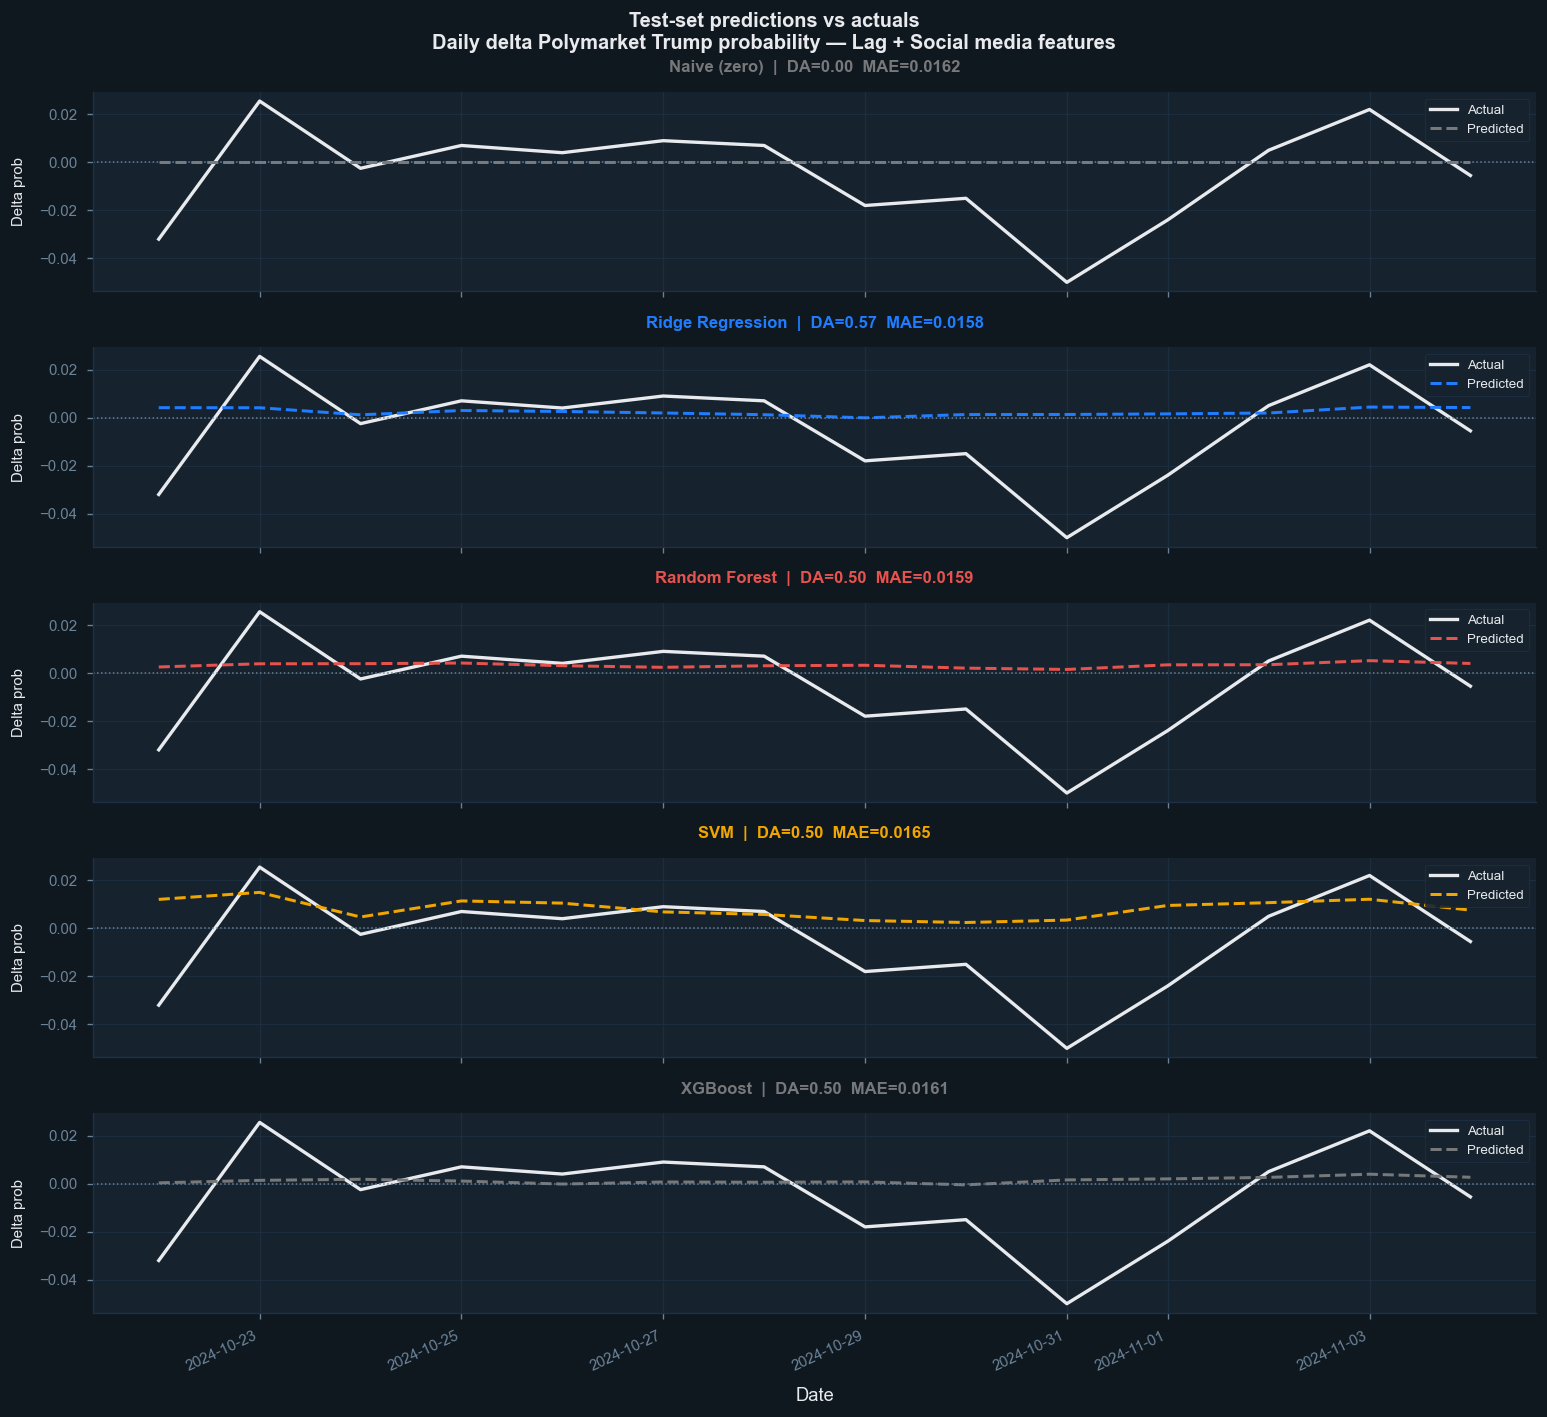

In [18]:
test_dates = df_test["date"].values
preds_list = [
    ("Naive (zero)",     naive_pred),
    ("Ridge Regression",  lr_pred),
    ("Random Forest",    rf_pred),
    ("SVM",              svm_pred),
    ("XGBoost",          xgb_pred),
]

fig, axes = plt.subplots(5, 1, figsize=(13, 12), sharex=True)
fig.patch.set_facecolor(BG_DARK)

for ax, (label, pred) in zip(axes, preds_list):
    ax.set_facecolor(BG_PANEL)
    ax.plot(test_dates, y_test, label="Actual",    color=TEXT_PRIMARY, linewidth=2)
    ax.plot(test_dates, pred,   label="Predicted", color=MODEL_COLORS[label],
            linewidth=1.8, linestyle="--")
    ax.axhline(0, color=TEXT_MUTED, linewidth=0.9, linestyle=":")
    da  = directional_accuracy(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    ax.set_title(f"{label}  |  DA={da:.2f}  MAE={mae:.4f}",
                 color=MODEL_COLORS[label], fontweight="bold", fontsize=10)
    ax.set_ylabel("Delta prob", color=TEXT_PRIMARY, fontsize=9)
    ax.legend(loc="upper right", facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
              labelcolor=TEXT_PRIMARY, fontsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
    ax.tick_params(colors=TEXT_MUTED)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)

axes[-1].set_xlabel("Date", color=TEXT_PRIMARY)
plt.xticks(rotation=25, ha="right")
fig.suptitle("Test-set predictions vs actuals\nDaily delta Polymarket Trump probability — Lag + Social media features",
             color=TEXT_PRIMARY, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

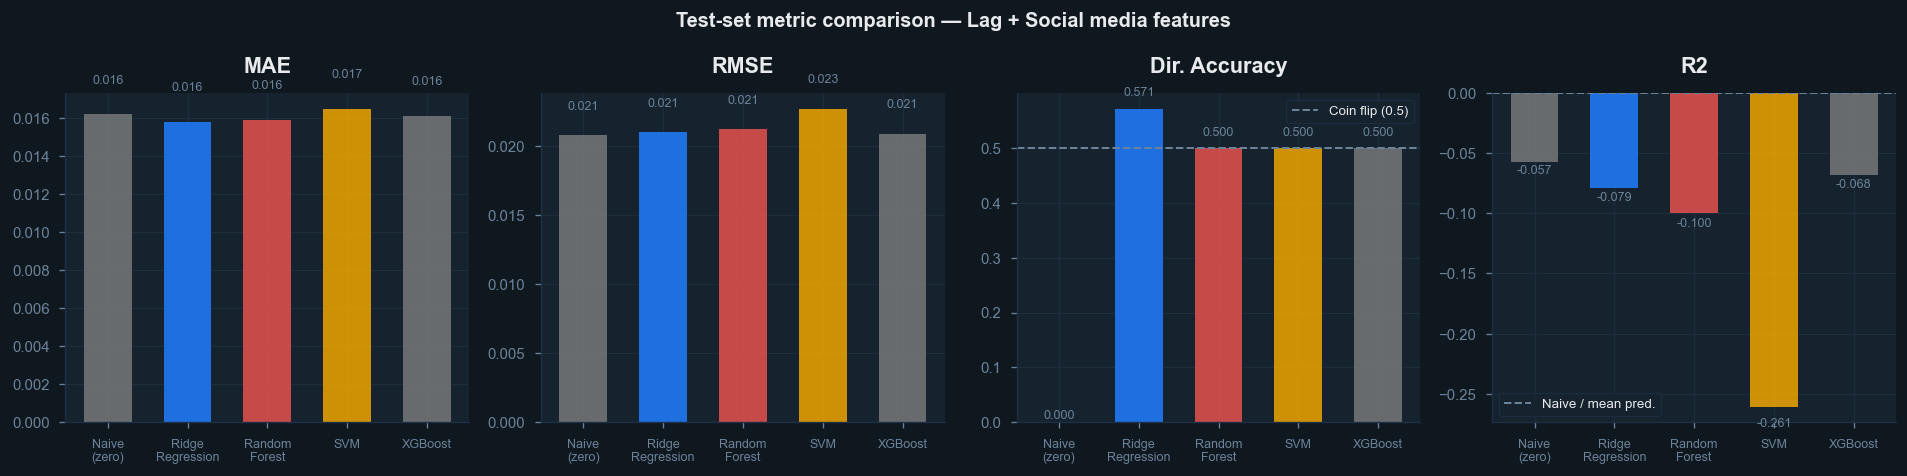

In [19]:
metrics_plot = ["MAE", "RMSE", "Dir. Accuracy", "R2"]
model_names  = list(MODEL_COLORS.keys())
colors_list  = list(MODEL_COLORS.values())

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.patch.set_facecolor(BG_DARK)

for ax, metric in zip(axes, metrics_plot):
    ax.set_facecolor(BG_PANEL)
    vals = [test_summary.loc[m, metric] for m in model_names]
    bars = ax.bar(range(len(model_names)), vals, color=colors_list, alpha=0.85, width=0.6)

    if metric == "Dir. Accuracy":
        ax.axhline(0.5, color=TEXT_MUTED, linestyle="--", linewidth=1.2, label="Coin flip (0.5)")
    if metric == "R2":
        ax.axhline(0, color=TEXT_MUTED, linestyle="--", linewidth=1.2, label="Naive / mean pred.")

    for bar, val in zip(bars, vals):
        offset = abs(val) * 0.03 + 0.001
        va     = "bottom" if val >= 0 else "top"
        y_pos  = bar.get_height() + offset if val >= 0 else bar.get_height() - offset
        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                f"{val:.3f}", ha="center", va=va, fontsize=7.5, color=TEXT_MUTED)

    ax.set_title(metric, color=TEXT_PRIMARY, fontweight="bold")
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([m.replace(" ", "\n") for m in model_names],
                       fontsize=7.5, color=TEXT_MUTED)
    for spine in ax.spines.values(): spine.set_edgecolor(SPINE_COLOR)
    ax.tick_params(colors=TEXT_MUTED)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.7)
    ax.set_axisbelow(True)
    if metric in ("Dir. Accuracy", "R2"):
        ax.legend(facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY, fontsize=8)

fig.suptitle("Test-set metric comparison — Lag + Social media features",
             color=TEXT_PRIMARY, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [20]:
from pathlib import Path

# ── Export test-set results to CSV for model_analysis.ipynb ──────────────────
FEATURE_SET = "Lag+Social (64f)"
CSV_NAME    = "lag_social_64f.csv"
OUT_DIR     = Path("../../4_model_analysis/results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

df_export = test_summary.copy()
df_export.index.name = "Model"
df_export = df_export.reset_index()
df_export = df_export.rename(columns={"Dir. Accuracy": "DA"})
df_export["Model"] = df_export["Model"].replace({"Ridge Regression": "Ridge", "OLS": "OLS"})
df_export.insert(0, "Feature_set", FEATURE_SET)

out_path = OUT_DIR / CSV_NAME
df_export.to_csv(out_path, index=False)
print(f"Results saved → {out_path}")
display(df_export)

Results saved → ..\..\4_model_analysis\results\lag_social_64f.csv


,Feature_set,Model,MAE,RMSE,DA,R2
0,Lag+Social (64f),Naive (zero),0.0162,0.0208,0.0000,-0.0570
1,Lag+Social (64f),Ridge,0.0158,0.0210,0.5714,-0.0788
2,Lag+Social (64f),Random Forest,0.0159,0.0212,0.5000,-0.0997
3,Lag+Social (64f),SVM,0.0165,0.0227,0.5000,-0.2607
4,Lag+Social (64f),XGBoost,0.0161,0.0209,0.5000,-0.0679
